## Births data
In this task the principal competences revised and used were 
- pivot tables
- plot annotation
- sigma clipping (quartile based on Gaussian)

In [2]:
# Load the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
births = pd.read_csv("../data/births.csv")
births.head()


,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


Make a pivot table with a new column for decade of birth.

In [4]:
births["decade"] = 10 * (births["year"] // 10)
births.pivot_table("births", index="decade", columns="gender", aggfunc="sum")

gender,F,M
decade,,
1960,1753634,1846572
1970,16263075,17121550
1980,18310351,19243452
1990,19479454,20420553
2000,18229309,19106428


In [6]:
bpt = births.pivot_table("births", index="year", columns="gender", aggfunc="sum")

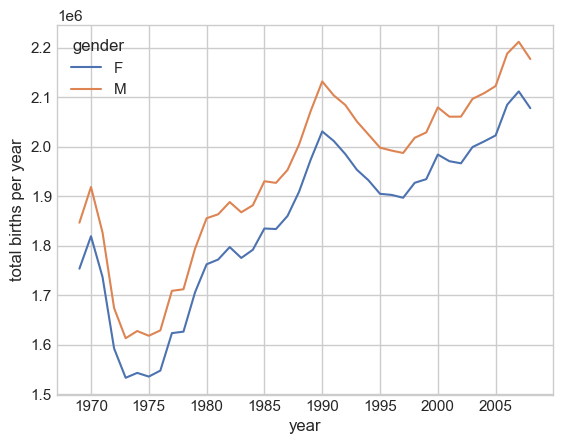

In [39]:
# births.pivot_table("births", index="year", columns="gender", aggfunc="sum").plot()
bpt.plot()
plt.ylabel("total births per year")
ax.set_ylim(1500000, 2500400);

A little house cleaning. Following Jake's example, we can remove outliers and missing values via sigma-clipping.

In [18]:
quartiles = np.percentile(births["births"], [25, 50, 75])
mu = quartiles[1] # remember it's 0-indexing
sig = 0.74 * (quartiles[2] - quartiles[0])

0.74 is interquartile range of a Gaussian distribution. To learn more -\o/-

In [8]:
births

,year,month,day,gender,births,decade
0,1969,1,1.0,F,4046,1960
1,1969,1,1.0,M,4440,1960
2,1969,1,2.0,F,4454,1960
3,1969,1,2.0,M,4548,1960
4,1969,1,3.0,F,4548,1960
...,...,...,...,...,...,...
15542,2008,10,NaN,M,183219,2000
15543,2008,11,NaN,F,158939,2000
15544,2008,11,NaN,M,165468,2000
15545,2008,12,NaN,F,173215,2000


In [11]:
mu, sig

(np.float64(4814.0), np.float64(689.31))

In [19]:
# This is to remove outliers and missing data in one move
births_clean = births.query("(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)")

In [20]:
births_clean

,year,month,day,gender,births,decade
0,1969,1,1.0,F,4046,1960
1,1969,1,1.0,M,4440,1960
2,1969,1,2.0,F,4454,1960
3,1969,1,2.0,M,4548,1960
4,1969,1,3.0,F,4548,1960
...,...,...,...,...,...,...
15062,1988,12,29.0,M,5944,1980
15063,1988,12,30.0,F,5742,1980
15064,1988,12,30.0,M,6095,1980
15065,1988,12,31.0,F,4435,1980


In [16]:
births.describe()

,year,month,day,births,decade
count,15547.000000,15547.000000,15067.000000,15547.000000,15547.000000
mean,1979.037435,6.515919,17.769894,9762.293561,1974.544285
std,6.728340,3.449632,15.284034,28552.465810,6.789583
min,1969.000000,1.000000,1.000000,1.000000,1960.000000
25%,1974.000000,4.000000,8.000000,4358.000000,1970.000000
50%,1979.000000,7.000000,16.000000,4814.000000,1970.000000
75%,1984.000000,10.000000,24.000000,5289.500000,1980.000000
max,2008.000000,12.000000,99.000000,199622.000000,2000.000000


In [20]:
births.isnull()

,year,month,day,gender,births,decade
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
15542,False,False,True,False,False,False
15543,False,False,True,False,False,False
15544,False,False,True,False,False,False
15545,False,False,True,False,False,False


In [21]:
births_clean.columns

Index(['year', 'month', 'day', 'gender', 'births', 'decade'], dtype='object')

In [23]:
# set the day column to integer. It's saved as float64
births_clean.astype({"day": int}).dtypes

year       int64
month      int64
day        int64
gender    object
births     int64
decade     int64
dtype: object

In [22]:
births_clean.dtypes

year        int64
month       int64
day       float64
gender     object
births      int64
decade      int64
dtype: object

In [24]:
# create a datetime index from the year month day
births_clean.index = pd.to_datetime(10000 * births_clean.year + 
                          100 * births_clean.month +
                          births_clean.day, format="%Y%m%d")

In [25]:
births_clean


,year,month,day,gender,births,decade
1969-01-01,1969,1,1.0,F,4046,1960
1969-01-01,1969,1,1.0,M,4440,1960
1969-01-02,1969,1,2.0,F,4454,1960
1969-01-02,1969,1,2.0,M,4548,1960
1969-01-03,1969,1,3.0,F,4548,1960
...,...,...,...,...,...,...
1988-12-29,1988,12,29.0,M,5944,1980
1988-12-30,1988,12,30.0,F,5742,1980
1988-12-30,1988,12,30.0,M,6095,1980
1988-12-31,1988,12,31.0,F,4435,1980


In [45]:
births_clean.dtypes


year        int64
month       int64
day       float64
gender     object
births      int64
decade      int64
dtype: object

In [46]:
births_clean

,year,month,day,gender,births,decade
1969-01-01,1969,1,1.0,F,4046,1960
1969-01-01,1969,1,1.0,M,4440,1960
1969-01-02,1969,1,2.0,F,4454,1960
1969-01-02,1969,1,2.0,M,4548,1960
1969-01-03,1969,1,3.0,F,4548,1960
...,...,...,...,...,...,...
1988-12-29,1988,12,29.0,M,5944,1980
1988-12-30,1988,12,30.0,F,5742,1980
1988-12-30,1988,12,30.0,M,6095,1980
1988-12-31,1988,12,31.0,F,4435,1980


In [27]:
births_clean.loc[:, "dayofweek"] = births_clean.index.dayofweek

In [28]:
births_clean

,year,month,day,gender,births,decade,dayofweek
1969-01-01,1969,1,1.0,F,4046,1960,2
1969-01-01,1969,1,1.0,M,4440,1960,2
1969-01-02,1969,1,2.0,F,4454,1960,3
1969-01-02,1969,1,2.0,M,4548,1960,3
1969-01-03,1969,1,3.0,F,4548,1960,4
...,...,...,...,...,...,...,...
1988-12-29,1988,12,29.0,M,5944,1980,3
1988-12-30,1988,12,30.0,F,5742,1980,4
1988-12-30,1988,12,30.0,M,6095,1980,4
1988-12-31,1988,12,31.0,F,4435,1980,5


### Using this, let's plot birth by weekday (dayofweek)

/tmp/ipykernel_358653/156199193.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(["d", "Mon", "Tues", "Wed", "Thur", "Fri", "Sat", "Sun"])


Text(0, 0.5, 'mean births by day')

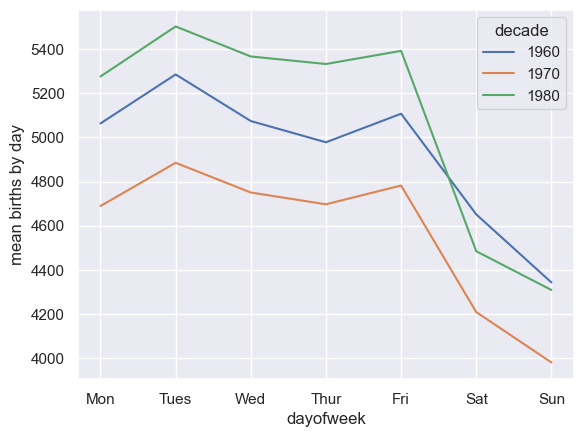

In [29]:
births_clean.pivot_table("births", index="dayofweek", columns="decade", aggfunc="mean").plot()
plt.gca().set_xticklabels(["d", "Mon", "Tues", "Wed", "Thur", "Fri", "Sat", "Sun"])
plt.ylabel("mean births by day")

In [30]:
births_clean.pivot_table("births", index="dayofweek", columns="decade", aggfunc="mean")

decade,1960,1970,1980
dayofweek,,,
0,5063.826923,4689.097701,5276.907249
1,5286.096154,4885.252399,5503.842553
2,5074.622642,4750.376200,5367.642553
3,4978.288462,4696.923372,5333.485106
4,5107.884615,4782.095785,5393.087234
5,4651.057692,4207.784483,4483.901064
6,4342.346154,3979.278736,4308.120469


Note: Fewer births at the weekends

In [69]:
births.loc[15300:,:]

,year,month,day,gender,births,decade
15300,1998,9,NaN,M,175254,1990
15301,1998,10,NaN,F,162998,1990
15302,1998,10,NaN,M,170140,1990
15303,1998,11,NaN,F,153386,1990
15304,1998,11,NaN,M,160161,1990
...,...,...,...,...,...,...
15542,2008,10,NaN,M,183219,2000
15543,2008,11,NaN,F,158939,2000
15544,2008,11,NaN,M,165468,2000
15545,2008,12,NaN,F,173215,2000


### Let's see mean number of births by day of year

In [31]:

births_by_date = births_clean.pivot_table("births", [births_clean.index.month, births_clean.index.day])
births_by_date

births
1  1   4009.225
   2   4247.400
   3   4500.900
   4   4571.350
   5   4603.625
...         ...
12 27  4850.150
   28  5044.200
   29  5120.150
   30  5172.350
   31  4859.200

[366 rows x 1 columns]

In [75]:
births_by_date.dtypes

births    float64
dtype: object

In [32]:
# create a leapyear datetime using 2012 as a dummy leap year
from datetime import datetime
births_by_date.index = pd.to_datetime([datetime(2012, month, day) for (month, day) in births_by_date.index])
births_by_date.head(8)

,births
2012-01-01,4009.225
2012-01-02,4247.400
2012-01-03,4500.900
2012-01-04,4571.350
2012-01-05,4603.625
2012-01-06,4668.150
2012-01-07,4706.925
2012-01-08,4629.650


This is showing the average number of births by day of year.

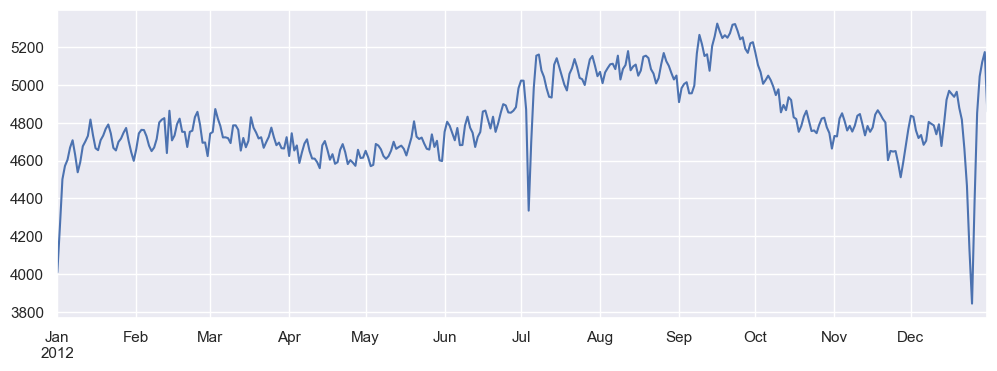

In [33]:
# Plot the results

fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax, legend=False);

## Modifying and annotating the plot above

In [35]:
import matplotlib as mpl
plt.style.use("seaborn-v0_8-whitegrid")

In [93]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

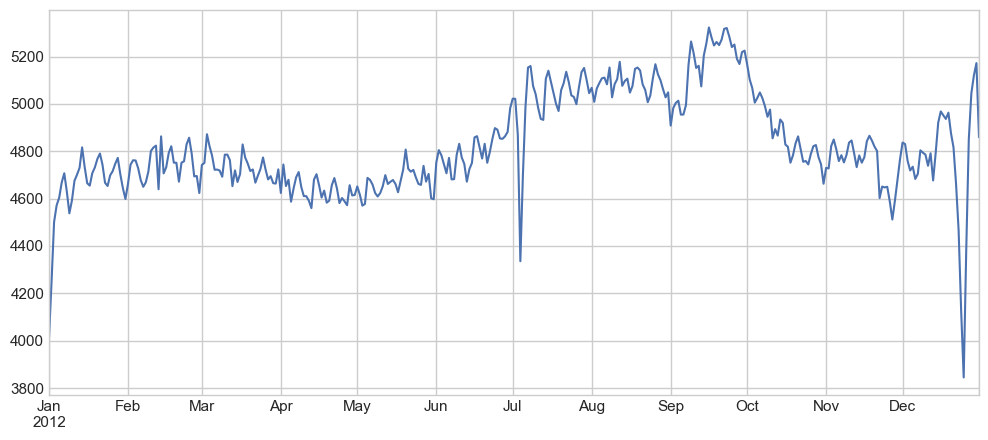

In [36]:
# Replot
fig, ax = plt.subplots(figsize=(12, 5))
births_by_date.plot(ax=ax, legend=False);

The annotations are done with the `plt.text` or `ax.text` command which puts the label at the given `x/y` position.

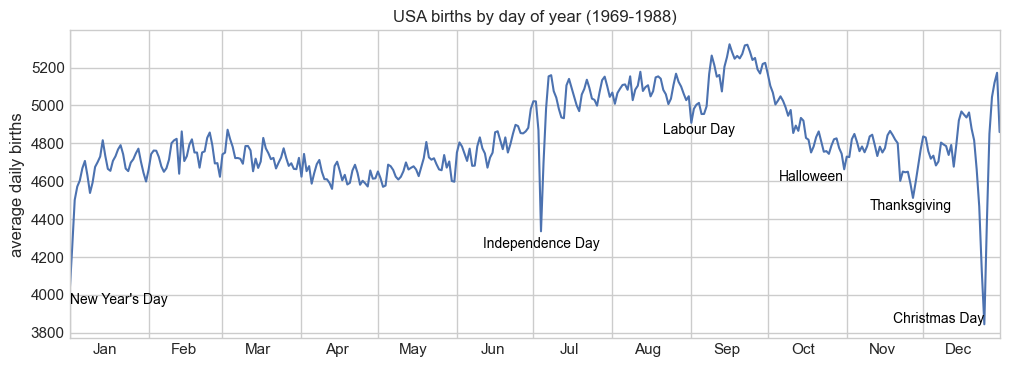

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax, legend=False);

# aDd labels
style = dict(size=10, color="black")

ax.text("2012-1-1", 3950, "New Year's Day", **style)
ax.text("2012-7-4", 4250, "Independence Day", ha="center", **style)
ax.text("2012-9-4", 4850, "Labour Day", ha="center", **style)
ax.text("2012-10-31", 4600, "Halloween", ha="right", **style)
ax.text("2012-11-26", 4450, "Thanksgiving", ha="center", **style)
ax.text("2012-12-25", 3850, "Christmas Day", ha="right", **style)

# title and label the plot
ax.set(title="USA births by day of year (1969-1988)",
       ylabel="average daily births")

# Format the x-axis by centering the month labels
ax.xaxis.set_major_locator(mpl.dates.MonthLocator())
ax.xaxis.set_minor_locator(mpl.dates.MonthLocator(bymonthday=15))
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.xaxis.set_minor_formatter(mpl.dates.DateFormatter("%h"));

## Another example of fancy annotations using matplotlib. Code is put here for reference.

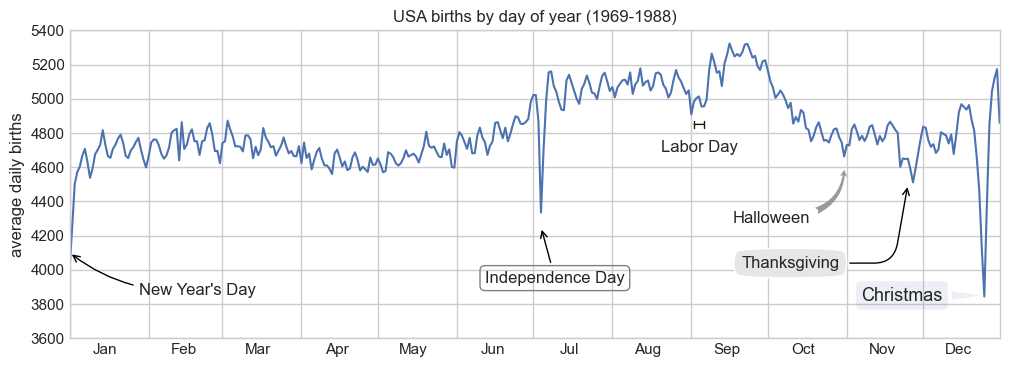

In [38]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax, legend=False)

# Add labels to the plot
ax.annotate("New Year's Day", xy=('2012-1-1', 4100),  xycoords='data',
            xytext=(50, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle="->",ec="black",
                            connectionstyle="arc3,rad=-0.2"))

ax.annotate("Independence Day", xy=('2012-7-4', 4250),  xycoords='data',
            bbox=dict(boxstyle="round", fc="none", ec="gray"),
            xytext=(10, -40), textcoords='offset points', ha='center',
            arrowprops=dict(arrowstyle="->", color="black"))

ax.annotate('Labor Day', xy=('2012-9-4', 4850), xycoords='data', ha='center',
            xytext=(0, -20), textcoords='offset points')
ax.annotate('', xy=('2012-9-1', 4850), xytext=('2012-9-7', 4850),
            xycoords='data', textcoords='data',
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 'ec': "k" },)

ax.annotate('Halloween', xy=('2012-10-31', 4600),  xycoords='data',
            xytext=(-80, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none", 
                            connectionstyle="angle3,angleA=0,angleB=-90"))

ax.annotate('Thanksgiving', xy=('2012-11-25', 4500),  xycoords='data',
            xytext=(-120, -60), textcoords='offset points',
            bbox=dict(boxstyle="round4,pad=.5", fc="0.9"),
            arrowprops=dict(arrowstyle="->", ec='black',
                            connectionstyle="angle,angleA=0,angleB=80,rad=20"))


ax.annotate('Christmas', xy=('2012-12-25', 3850),  xycoords='data',
             xytext=(-30, 0), textcoords='offset points',
             size=13, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.1),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.1))

# Label the axes
ax.set(title='USA births by day of year (1969-1988)',
       ylabel='average daily births')

# Format the x axis with centered month labels
ax.xaxis.set_major_locator(mpl.dates.MonthLocator())
ax.xaxis.set_minor_locator(mpl.dates.MonthLocator(bymonthday=15))
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.xaxis.set_minor_formatter(mpl.dates.DateFormatter('%h'));

ax.set_ylim(3600, 5400);

### Little Note
The API seems to have changed for arrows on New Year's Day, Independence, Labor and Thanksgiving.

_Fixed it by adding the color explicitly: ec="k", ec="black", color="black"._

They all give the same result.

[(-1.0, 5.0), (-4.0, 3.0)]

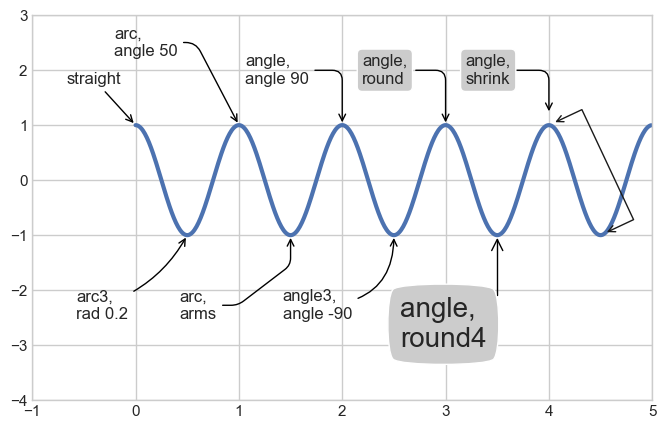

In [114]:
fig, ax = plt.subplots(figsize=(8, 5))

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)
line, = ax.plot(t, s, lw=3)

ax.annotate(
    'straight',
    xy=(0, 1), xycoords='data',
    xytext=(-50, 30), textcoords='offset points',
    arrowprops=dict(color='black', arrowstyle="->"))
ax.annotate(
    'arc3,\nrad 0.2',
    xy=(0.5, -1), xycoords='data',
    xytext=(-80, -60), textcoords='offset points',
    arrowprops=dict(arrowstyle="->",color='black',
                    connectionstyle="arc3,rad=.2"))
ax.annotate(
    'arc,\nangle 50',
    xy=(1., 1), xycoords='data',
    annotation_clip=False,
    xytext=(-90, 50), textcoords='offset points',
    arrowprops=dict(arrowstyle="->",color='black',
                    connectionstyle="arc,angleA=0,armA=50,rad=10"))
ax.annotate(
    'arc,\narms',
    xy=(1.5, -1), xycoords='data',
    xytext=(-80, -60), textcoords='offset points',
    arrowprops=dict(
        arrowstyle="->", color='black',
        connectionstyle="arc,angleA=0,armA=40,angleB=-90,armB=30,rad=7"))
ax.annotate(
    'angle,\nangle 90',
    xy=(2., 1), xycoords='data',
    xytext=(-70, 30), textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color='black',
                    connectionstyle="angle,angleA=0,angleB=90,rad=10"))
ax.annotate(
    'angle3,\nangle -90',
    xy=(2.5, -1), xycoords='data',
    xytext=(-80, -60), textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color='black',
                    connectionstyle="angle3,angleA=0,angleB=-90"))
ax.annotate(
    'angle,\nround',
    xy=(3., 1), xycoords='data',
    xytext=(-60, 30), textcoords='offset points',
    bbox=dict(boxstyle="round", fc="0.8"),
    arrowprops=dict(arrowstyle="->", color='black',
                    connectionstyle="angle,angleA=0,angleB=90,rad=10"))
ax.annotate(
    'angle,\nround4',
    xy=(3.5, -1), xycoords='data',
    xytext=(-70, -80), textcoords='offset points',
    size=20,
    bbox=dict(boxstyle="round4,pad=.5", fc="0.8"),
    arrowprops=dict(arrowstyle="->", color='black',
                    connectionstyle="angle,angleA=0,angleB=-90,rad=10"))
ax.annotate(
    'angle,\nshrink',
    xy=(4., 1), xycoords='data',
    xytext=(-60, 30), textcoords='offset points',
    bbox=dict(boxstyle="round", fc="0.8"),
    arrowprops=dict(arrowstyle="->",
                    shrinkA=0, shrinkB=10, color='black',
                    connectionstyle="angle,angleA=0,angleB=90,rad=10"))
# You can pass an empty string to get only annotation arrows rendered
ax.annotate('', xy=(4., 1.), xycoords='data',
            xytext=(4.5, -1), textcoords='data',
            arrowprops=dict(arrowstyle="<->",
                            connectionstyle="bar",
                            ec="k",
                            shrinkA=5, shrinkB=5))

ax.set(xlim=(-1, 5), ylim=(-4, 3))